In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib as mpl

import sys
sys.path.append('/home/rkievit/masterproject/masterproject/src')
sys.path.append('F:\\OneDrive - Telecom Business Transformers BV\\School\\Uni\\MSc Year 2\\Master Research Project\\Project\\masterproject\\src')

from data_queries import query_extra_data



In [63]:
#plt.style.available
plt.style.use('default')
mpl.rcParams['axes.grid'] = True
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['font.size'] = 11
mpl.rcParams['font.family'] = 'serif'

In [113]:
radius = '1as'
method = 'nearest'

rpath = '../../results/'
fpath = '../../../figures/'
dpath = '../../../data/' 
xm_all = np.load(rpath+'crossmatch_1as_all_neighbours.npy')
xm_near = np.load(rpath+'crossmatch_1as_best_neighbour_nearest.npy')
xm_bright = np.load(rpath+'crossmatch_1as_best_neighbour_brightest.npy') 

xm = np.load(rpath+f'crossmatch_{radius}_best_neighbour_{method}.npy')

In [114]:
xm_near

array([[                  1, 2738327528519591936,             9944741],
       [                  2, 2341871673090078592,             9935191],
       [                  3, 2881742980523997824,             5993693],
       ...,
       [             120402, 5290832364972775808,             6070997],
       [             120403, 5290725643625189504,             9877788],
       [             120404, 5290820682661822848,             6020356]],
      dtype=int64)

In [107]:
# Get Gaia data
extra_gdata = ['phot_g_mean_mag', 'pmra', 'pmdec', 'pmra_error', 'pmdec_error']
xm_all, gdata_all = query_extra_data(xm_all, extra_gdata)
xm_near, gdata_near = query_extra_data(xm_near, extra_gdata)
xm_bright, gdata_bright = query_extra_data(xm_bright, extra_gdata)

# Get Hipp data
extra_hdata = ['hp_mag', 'b_v']
xm_all, hdata_all = query_extra_data(xm_all, extra_hdata, cat='hipp')
xm_near, hdata_near = query_extra_data(xm_near, extra_hdata, cat='hipp')
xm_bright, hdata_bright = query_extra_data(xm_bright, extra_hdata, cat='hipp')

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INF

## Hipparcos Values Matched vs. Unmatched

In [8]:
hipp = fits.open(dpath+'Hipparcos2.fits')[1].data
hip_ids = hipp['hip']

hip_matched = [] # Appending slow but whatever
hip_nomatch = []

for i,hip in enumerate(hip_ids):
    if hip in xm[:,0]:
        hip_matched.append(i)
    else:
        hip_nomatch.append(i)
hip_matched = np.array(hip_matched)
hip_nomatch = np.array(hip_nomatch)

KeyboardInterrupt: 

In [ ]:
print(f"Number of matched Hipparcos stars: {hip_matched.shape[0]}")
print(f"Number of unmatched Hipparcos stars: {hip_nomatch.shape[0]}")

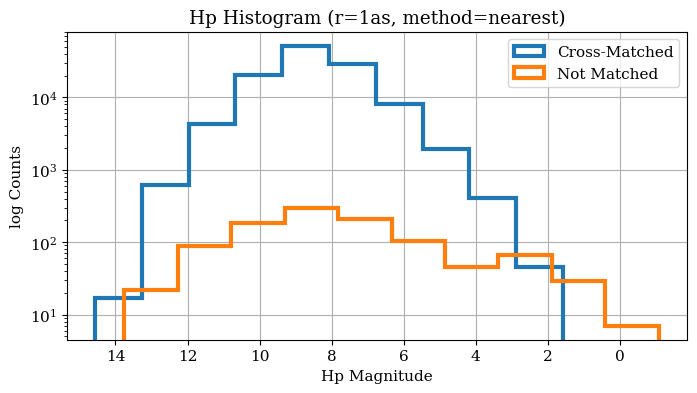

In [14]:
# Compare histograms of magnitude
fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(hipp['hp_mag'][hip_matched], histtype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(hipp['hp_mag'][hip_nomatch], histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Hp Magnitude')
ax.set_ylabel('log Counts')
ax.set_title(f"Hp Histogram (r={radius}, method={method})")
ax.invert_xaxis()

plt.legend()
plt.show()

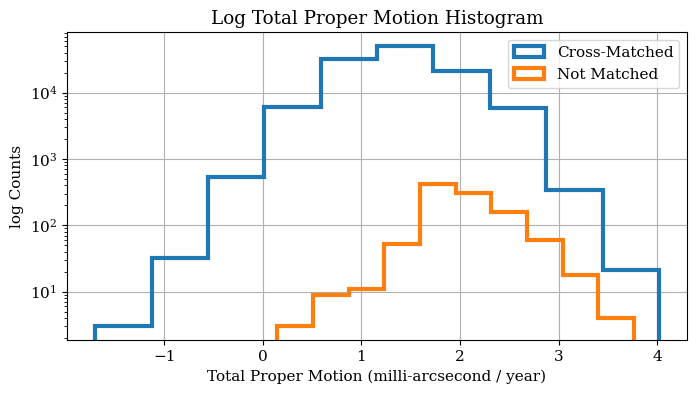

In [19]:
# Compare histogram of proper mitions
pm_matched = np.sqrt((hipp['pm_ra'][hip_matched]**2.) + (hipp['pm_de'][hip_matched]**2))
pm_nomatch = np.sqrt((hipp['pm_ra'][hip_nomatch]**2.) + (hipp['pm_de'][hip_nomatch]**2))

fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(np.log10(pm_matched), histtype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(np.log10(pm_nomatch), histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Total Proper Motion (milli-arcsecond / year)')
ax.set_ylabel('log Counts')
ax.set_title(f"Log Total Proper Motion Histogram")


plt.legend()
plt.show()

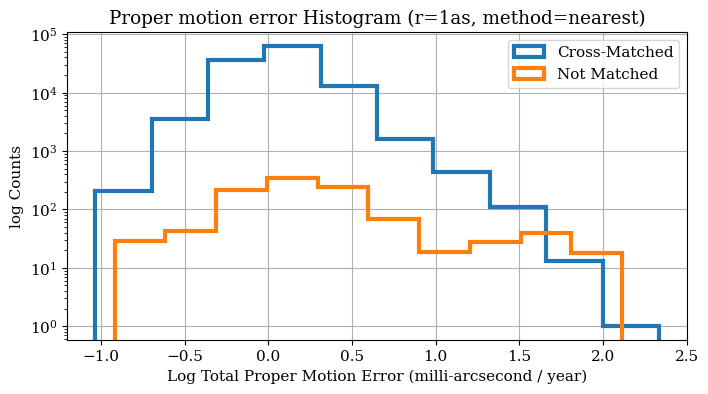

In [23]:
# Compare histogram of proper motion errors
e_pm_matched = np.sqrt((hipp['e_pm_ra'][hip_matched]**2.) + (hipp['e_pm_de'][hip_matched]**2))
e_pm_nomatch = np.sqrt((hipp['e_pm_ra'][hip_nomatch]**2.) + (hipp['e_pm_de'][hip_nomatch]**2))

fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(np.log10(e_pm_matched),histtype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(np.log10(e_pm_nomatch), histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Log Total Proper Motion Error (milli-arcsecond / year)')

ax.set_ylabel('log Counts')
ax.set_title(f"Proper motion error Histogram (r={radius}, method={method})")

plt.legend()
plt.show()

## Gaia properties of Matched objects

In [9]:
match_method = 'nearest'
print(extra_gdata)
print(extra_hdata)
hipp_bv = hdata_near[:,1]
hp_mag = hdata_near[:,0]
gaia_g = gdata_near[:,0]

['phot_g_mean_mag', 'pmra', 'pmdec', 'pmra_error', 'pmdec_error']
['hp_mag', 'b_v']


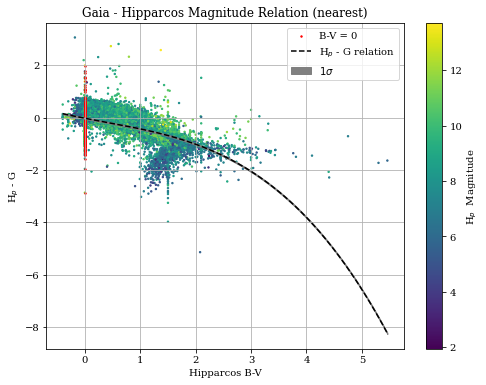

In [7]:
# G - Hp relation reported on the gaia archive doccs
x = np.linspace(np.min(hipp_bv), np.max(hipp_bv), 1000)
y = -0.02392 - 0.4069*x + 0.04569*(x**2) - 0.0452*(x**3)
sigma = 0.02417

fig, ax = plt.subplots(1,1, figsize=(8, 6))
bv0_mask = np.where(hipp_bv==0.)

scatter = ax.scatter(hipp_bv, gaia_g-hp_mag, s=2, c=gaia_g)
ax.scatter(hipp_bv[bv0_mask], (gaia_g-hp_mag)[bv0_mask], s=2, c='red', label='B-V = 0')
ax.plot(x,y,c='black',ls='--', label=f"H$_p$ - G relation")
ax.fill_between(x,y-sigma,y+sigma, color='gray', label=f'$1\sigma$')
cb = plt.colorbar(scatter)
cb.set_label(f"H$_p$  Magnitude")

ax.set_ylabel(f"H$_p$ - G")
ax.set_xlabel("Hipparcos B-V")
ax.set_title(f"Gaia - Hipparcos Magnitude Relation ({match_method})")

plt.legend()

plt.savefig(fpath+'gaiapred_bvcol.png', bbox_inches='tight')
plt.show()

The white line is the assumption we have made for the limit of the magnitude of Gaia objects, this line should perfectly match with the observations if this relation exactly holds. If an object lies above this black line, then Hp - G is bigger, and thus the Gaia star is brighter. If the star is below the line, then the Gaia star is less bright then we had assumed

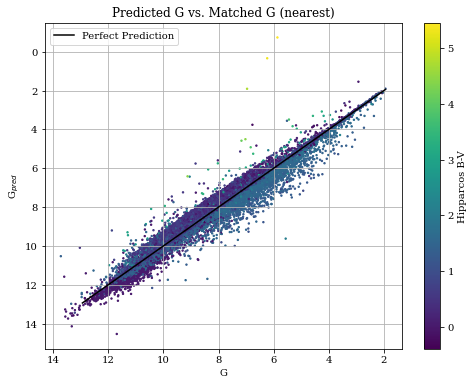

In [8]:
# Difference between G_pred and matched G
x = hipp_bv
G_pred = -0.02392 - 0.4069*x + 0.04569*(x**2) - 0.0452*(x**3) + hp_mag
best_line = np.arange(min(gaia_g), max(gaia_g))

fig, ax = plt.subplots(1,1, figsize=(8,6))

scatter = ax.scatter(gaia_g, G_pred, s=2, c=hipp_bv)
cb = plt.colorbar(scatter)
cb.set_label("Hipparcos B-V")
ax.plot(best_line, best_line, c='black', label="Perfect Prediction")

ax.set_xlabel("G")
ax.set_ylabel("G$_{pred}$")
ax.set_title(f"Predicted G vs. Matched G ({match_method})")
ax.invert_xaxis()
ax.invert_yaxis()


plt.legend()
plt.savefig(fpath+'gaiapred_gaiamatch.png', bbox_inches='tight')
plt.show()

In [116]:
pos_gaia_params = ['ra_prop', 'dec_prop', 'e_ra_prop', 'e_de_prop', 'ra_dec_prop']
pos_hipp_params = ['ra', 'dec', 'e_ra_rad', 'e_de_rad', 'u2']
xm = xm_near

#xm, pos_gaia = query_extra_data(xm, pos_gaia_params, cat='GaiaBaseCat', cat_dpath='../../../data/')
# Difficult to query Gaia data because the cat file is too big.

_, pos_hipp_table = query_extra_data(xm, pos_hipp_params, cat='hipp')

cat_gaia = fits.open('../../../data/GaiaBaseCat.fits')[1].data
# This for loop populates the pos_gaia table following GaiaCat_ID in the xm tables.
pos_gaia_table = np.zeros((xm.shape[0], len(pos_gaia_params)))
for i, label in enumerate(pos_gaia_params):
    pos_gaia_table[:, i] = cat_gaia[label][xm[:,2]]

(116901, 3)
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Table 'xm_table' deleted.
(116901, 3)


In [32]:
# Manual cross match on a Gaia Cat. This is incredibly slow. Should be able to do this better.
# For nearest implementation. Do it only for those objects where it is necessary
# The below code is for a full run.
pos_gaia = np.zeros((xm.shape[0], len(pos_gaia_params)))
for i,gaia_id in enumerate(xm[:,1]):
    cat_idx = np.where(cat_gaia['source_id'] == gaia_id)
    for j, label in enumerate(pos_gaia_params):
        pos_gaia[i][j] = cat_gaia[cat_idx][label]
    print(f'{i}/{xm.shape[0]}', end='\r')

KeyboardInterrupt: 

In [38]:
xm = xm_all_2

In [57]:
# The indexing here is absolutely terrible. But it works
# Plot double candidate stars
u, idx, c = np.unique(xm[:, 0], return_counts=True, return_index=True)
doubles = idx[c>1]

#random_choice = np.random.choice(doubles)
random_choice = np.random.choice(idx)
random_idx = np.where(idx == random_choice)[0][0] # assumes it only occurs once. Which it must because np.unique

hipp_id = u[random_idx]
pos_hipp = pos_hipp_table[idx[random_idx]]

gaia_ids = xm[idx[random_idx]][1]
pos_gaia = pos_gaia_table[idx[random_idx]: idx[random_idx] + c[random_idx]]




#gaia_ids = []
#pos_gaia = np.zeros((c[random_idx], len(pos_gaia_params)+1))
#
#for i in range(c[random_idx]):
#    gaia_cat_idx = np.where(cat_gaia['source_id'] == xm[idx[random_idx]+i][1])
#
#    for j, label in enumerate(pos_gaia_params):
#        pos_gaia[i][j] = cat_gaia[gaia_cat_idx][label]
#    pos_gaia[i][-1] = xm[random_idx+i][1]

In [65]:
print(pos_hipp, pos_gaia)

[ 2.07530552e+02  4.78211299e+01  8.70000000e-01  1.29000000e+00
 -6.00000000e-02] [[2.07530553e+02 4.78211280e+01 4.70954422e-01 5.38399631e-01
  1.30997737e-01]]


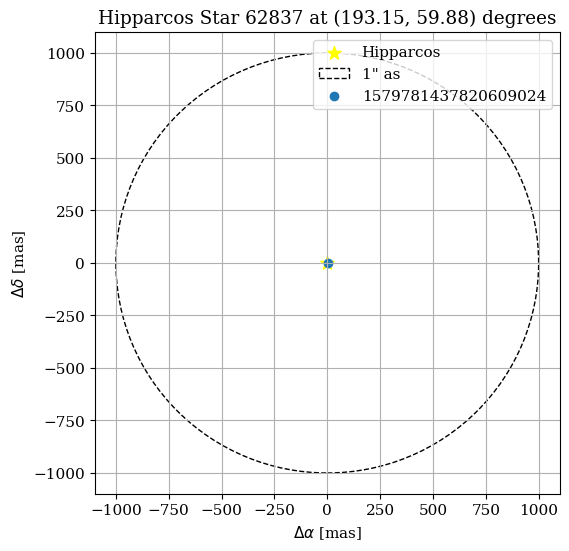

Distance between Gaia and Hipparcos object is 5.08 mas
This corresponds to 5.52262303219911 sigma_hipparcos.


In [89]:
ei = 1 # error inflation for testing

u, idx, c = np.unique(xm[:, 0], return_counts=True, return_index=True)
doubles = idx[c>1]

#random_choice = np.random.choice(doubles)
random_choice = np.random.choice(idx)
random_idx = np.where(idx == random_choice)[0][0] # assumes it only occurs once. Which it must because np.unique

hipp_id = u[random_idx]
pos_hipp = pos_hipp_table[idx[random_idx]]

gaia_ids = [xm[idx[random_idx]][1]]
pos_gaia = pos_gaia_table[idx[random_idx]: idx[random_idx] + c[random_idx]]

from matplotlib.patches import Circle, Ellipse


cs_radius = 1
fig, ax = plt.subplots(1,1, figsize=(6,6))

ra_h = pos_hipp[0] * 3600 * 1e3
de_h = pos_hipp[1] * 3600 * 1e3

ax.scatter(0, 0, s=100, c='yellow', marker='*',label='Hipparcos')
hipp_err_ellipse = Ellipse((0,0), ei*pos_hipp[2], ei*pos_hipp[3], fill=False, ec='yellow')
ax.add_patch(hipp_err_ellipse)


conesearch_circle = Circle((0,0), cs_radius * 1e3, fill=False, ec='black', ls='--', label=f'{cs_radius}" as')
ax.add_patch(conesearch_circle)

for i,pos in enumerate(pos_gaia):

    ra = pos[0] * 3600 * 1e3
    de = pos[1] * 3600 * 1e3
    ax.scatter(ra - ra_h, de - de_h,  label=np.int64(gaia_ids[i]), c=f'C{i}')
    gaia_err_ellipse = Ellipse((ra - ra_h, de - de_h), ei*pos[2], ei*pos[3], fill=False, color=f'C{i}')

    ax.add_patch(gaia_err_ellipse)

ax.set_xlabel(r"$\Delta\alpha$ [mas]")
ax.set_ylabel(r"$\Delta\delta$ [mas]")
ax.set_title(f"Hipparcos Star {hipp_id} at ({pos_hipp[0]:.2f}, {pos_hipp[1]:.2f}) degrees")

#plt.savefig('../../../figures/example_skyplot_sigma.png', bbox_inches='tight')

#sq_scale = 5 # mas
#ax.set_xlim(-sq_scale, +sq_scale)
#ax.set_ylim(-sq_scale, +sq_scale)

#plt.savefig('../../../figures/example_skyplot_sigma_zoomed.png', bbox_inches='tight')

plt.legend()
plt.show()


ra_h = np.radians(pos_hipp[0])
de_h = np.radians(pos_hipp[1])
ra_g = np.radians(pos_gaia[0][0])
de_g = np.radians(pos_gaia[0][1])

factor1 = (ra_h - ra_g) * np.cos(np.radians(de_h))
factor2 = de_h - de_g
distance = np.sqrt((factor1 ** 2) + (factor2 ** 2))
distance_mas = 3600 * 1e3 * np.degrees(distance)

avg_hipp_error = np.sqrt(pos_hipp[2]**2 + pos_hipp[3]**2)
error_w_distance = distance_mas/avg_hipp_error # avg_hipp_error is supposed to be in mas

print(f"Distance between Gaia and Hipparcos object is {distance_mas:.2f} mas")
print(f"This corresponds to {error_w_distance} sigma_hipparcos.")

#dist = angular_distance2(pos_hipp[0], pos_hipp[1], pos_gaia[0][0], pos_gaia[0][1], unit='degrees')


In [95]:
print(pos_gaia_params)
print(pos_hipp_params)

['ra_prop', 'dec_prop', 'e_ra_prop', 'e_de_prop', 'ra_dec_prop']
['ra', 'dec', 'e_ra_rad', 'e_de_rad', 'u2']


In [119]:

distances = angular_distance(pos_hipp_table[:,0], pos_hipp_table[:,1], pos_gaia_table[:,0], pos_gaia_table[:,1], unit='degrees')
distances_mas = np.degrees(distances) * 3600 * 1e3
avg_hipp_errors = np.sqrt((pos_hipp_table[:, 2])**2 + (pos_hipp_table[:, 3])**2)
error_w_distances = distances_mas / avg_hipp_errors

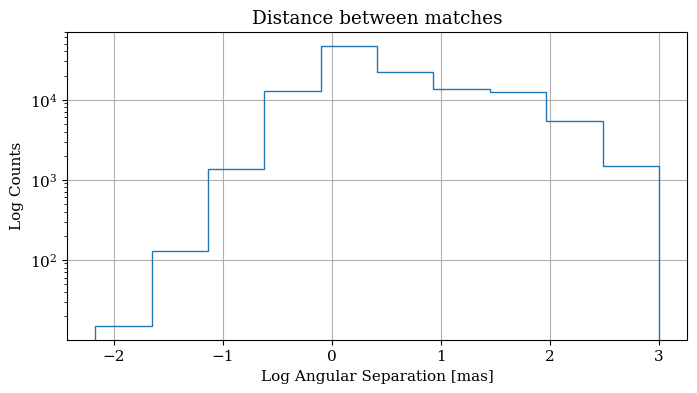

In [125]:
# Distances Histogram
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(np.log10(distances_mas), log=True, histtype='step')

ax.set_xlabel("Log Angular Separation [mas]")
ax.set_ylabel("Log Counts")
ax.set_title("Distance between matches")

plt.savefig(fpath+"1as_nearest_angsep.png", bbox_inches='tight')
plt.show()


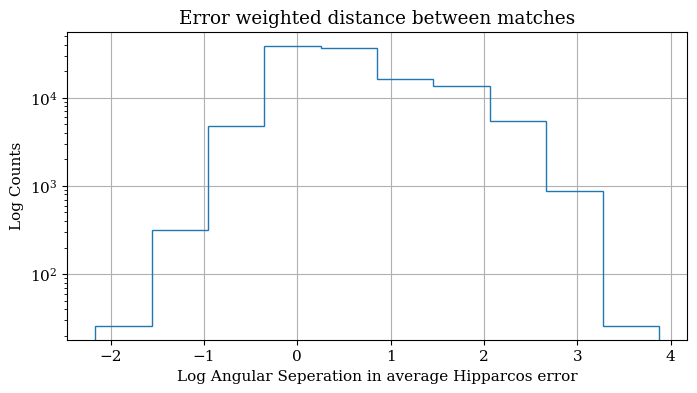

In [126]:
# Error weighted distance Histogram
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(np.log10(error_w_distances), log=True, histtype='step')

ax.set_xlabel("Log Angular Seperation in average Hipparcos error")
ax.set_ylabel("Log Counts")
ax.set_title("Error weighted distance between matches")

plt.savefig(fpath+"1as_nearest_ewdist.png", bbox_inches='tight')
plt.show()